In [4]:
import numpy as np
import pandas as pd
import statistics

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)


In [5]:
data = pd.read_csv("../data/data.csv", index_col=0)
print(data)

      country time_of_day        lat       long       road_type  \
8459       SE         day  55.604209  13.028574            city   
85589      IT       night  41.794853  12.522880         highway   
90649      DE         day  49.182153   9.414737         highway   
48806      SE         day  55.576732  13.013051            city   
35874      IT         day  45.478483   9.200364            city   
...       ...         ...        ...        ...             ...   
62575      PL         day  54.415335  18.566261  arterial-urban   
93595      PL       night  50.325703  18.943637  arterial-urban   
74962      PL         day  54.378439  18.605984  arterial-urban   
90673      PL         day  50.253217  19.823732   smaller-rural   
24373      DE         day  50.931399   6.953686            city   

      road_condition              weather  solar_angle_elevation  month  hour  \
8459          normal               cloudy              36.560248      5    14   
85589         normal          cle

In [6]:
all_columns = data.columns    

print(f"Number of rows: {data.shape[0]}")
print(f"Columns: {all_columns}")
print(f"Number of columns: {len(all_columns)}")

Number of rows: 7999
Columns: Index(['country', 'time_of_day', 'lat', 'long', 'road_type', 'road_condition',
       'weather', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'rain', 'snowfall', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'sunshine_duration',
       'wind_speed_10m', 'weather_code', 'laplacian', 'quality', 'brightness',
       'noisiness', 'sharpness', 'contrast', 'complexity', 'conf', 'iou',
       'lrp', 'pq'],
      dtype='object')
Number of columns: 31


In [7]:
numeric_columns = ['lat', 'long', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'sunshine_duration', 'wind_speed_10m', 'conf',  'laplacian', 'quality', 'brightness', 'noisiness', 'sharpness', 'contrast', 'complexity', 
       'iou', 'lrp', 'pq']
#'precipitation',

categorical_columns = ['time_of_day', 'country', 'road_type', 'road_condition',
       'weather', 'weather_code']

assert len(all_columns) == (len(categorical_columns) + len(numeric_columns)), "Columns not match"


# EDA

## Categorical Variables

In [8]:
print(f"Number of categorical features: {len(categorical_columns)}")
for col in categorical_columns:
    print("-" * 10)
    print(f"Column: {col}")
    print(f"Unique values: {data[col].nunique()}")
    print(f"Most common: {data[col].mode().iloc[0] if not data[col].mode().empty else 'N/A'}")
    print(f"Missing values: {data[col].isnull().sum()}")

Number of categorical features: 6
----------
Column: time_of_day
Unique values: 3
Most common: day
Missing values: 0
----------
Column: country
Unique values: 9
Most common: DE
Missing values: 0
----------
Column: road_type
Unique values: 5
Most common: city
Missing values: 0
----------
Column: road_condition
Unique values: 3
Most common: normal
Missing values: 0
----------
Column: weather
Unique values: 9
Most common: partly-cloudy-day
Missing values: 0
----------
Column: weather_code
Unique values: 11
Most common: 3.0
Missing values: 0


Distribution

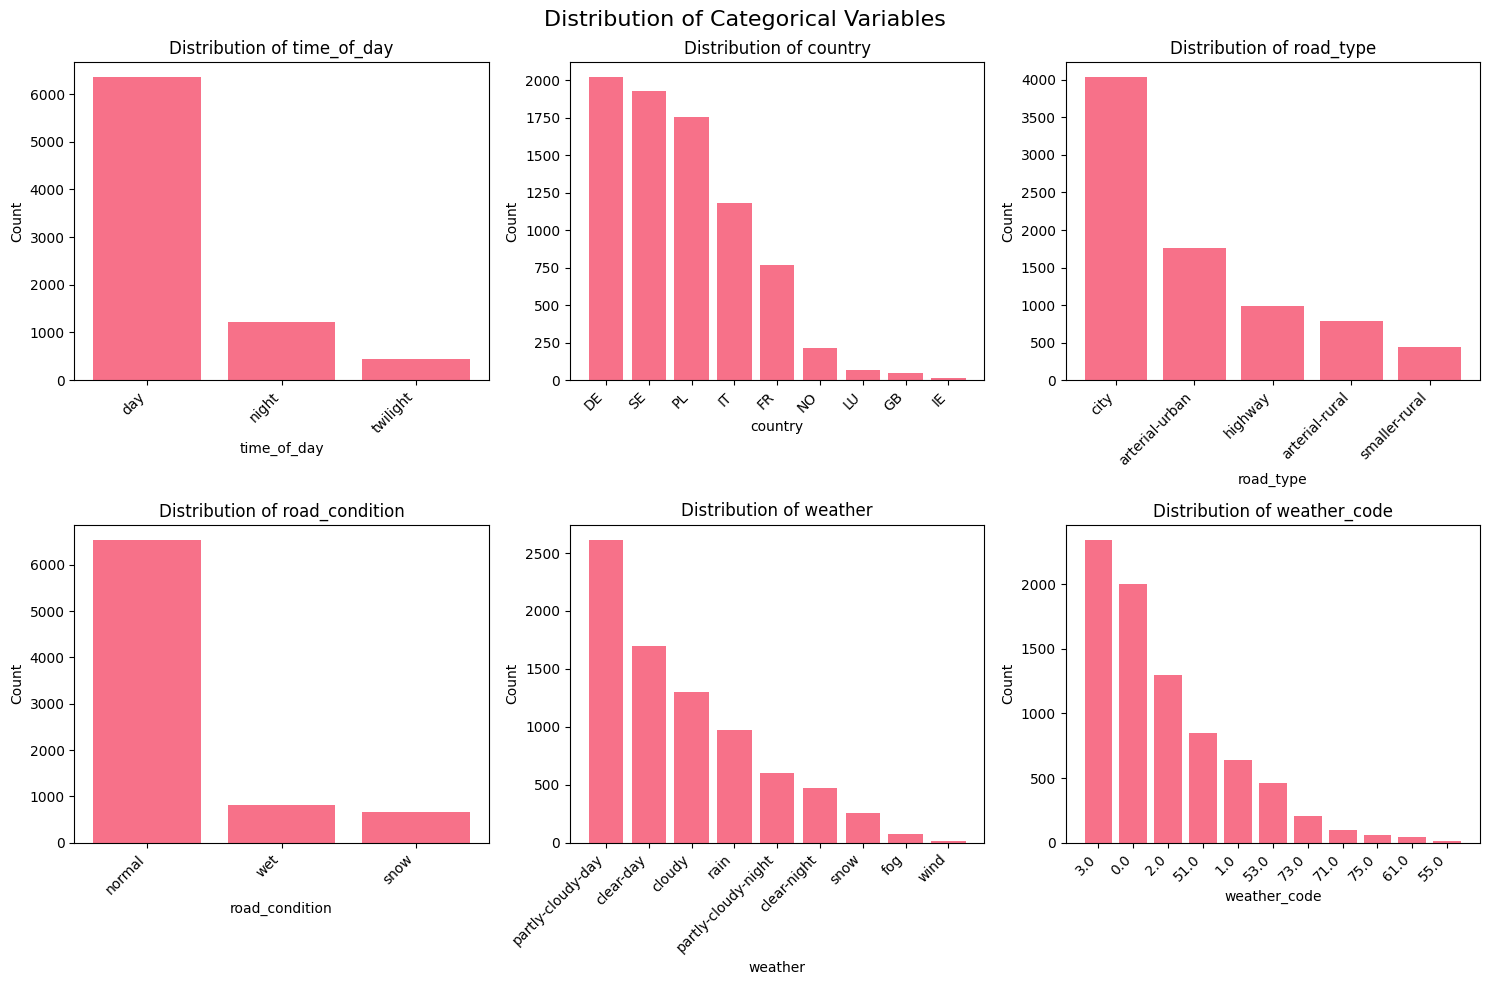

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    value_counts = data[column].value_counts()
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')


plt.tight_layout()
plt.show()

Correlation - Using Pearson and labels encoded

In [10]:

encoded_data = data[categorical_columns].copy()
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    encoded_data[column] = encoded_data[column].fillna('Unknown')
    encoded_data[column] = le.fit_transform(encoded_data[column])
    label_encoders[column] = le

pearson_corr = encoded_data.corr()
print(pearson_corr.round(3))

                time_of_day  country  road_type  road_condition  weather  \
time_of_day           1.000   -0.178      0.078           0.017    0.177   
country              -0.178    1.000     -0.028           0.161    0.002   
road_type             0.078   -0.028      1.000          -0.075   -0.071   
road_condition        0.017    0.161     -0.075           1.000    0.338   
weather               0.177    0.002     -0.071           0.338    1.000   
weather_code         -0.059    0.183     -0.094           0.444    0.568   

                weather_code  
time_of_day           -0.059  
country                0.183  
road_type             -0.094  
road_condition         0.444  
weather                0.568  
weather_code           1.000  


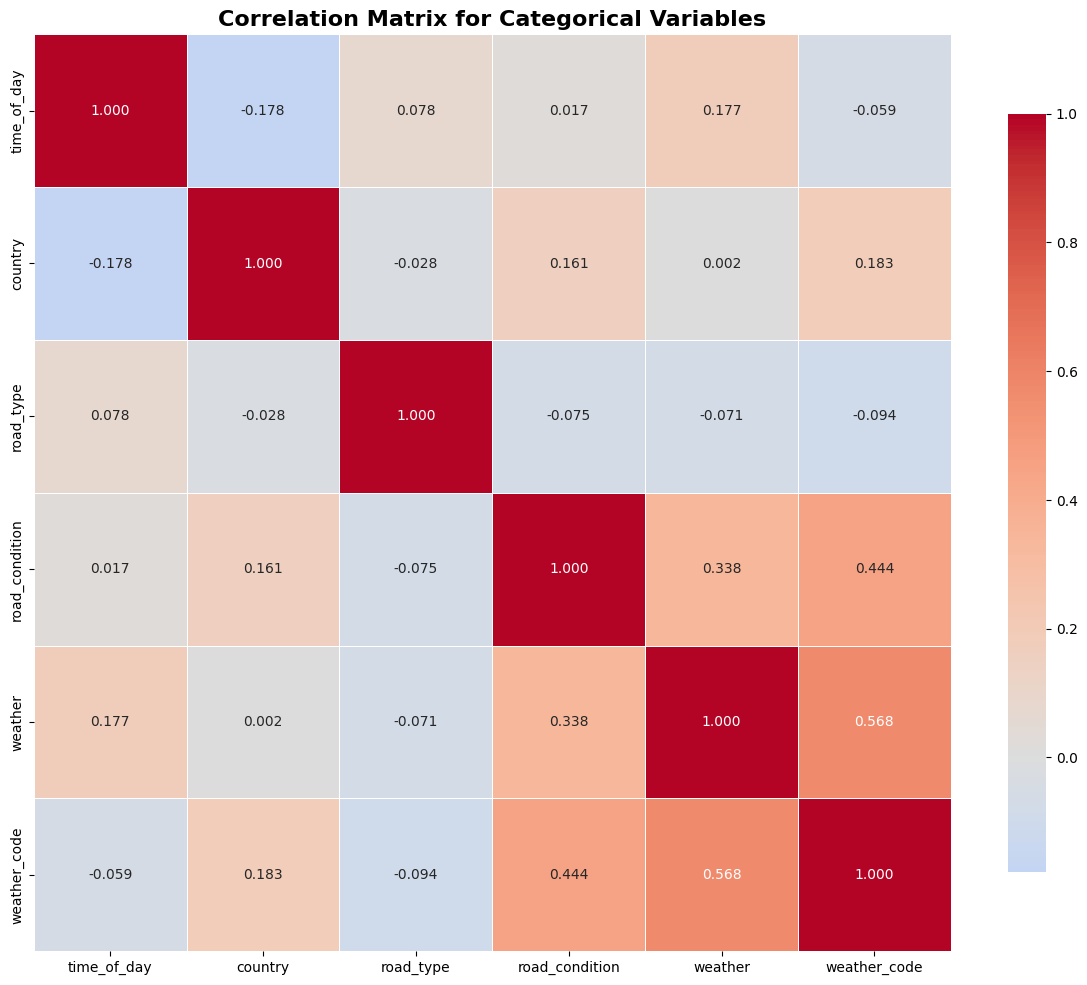

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.3f', cbar_kws={"shrink": .8})
plt.title("Correlation Matrix for Categorical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Numerical Variables 

In [12]:
print(f"Number of numerical features: {len(numeric_columns)}")
for col in numeric_columns:
    if col == 'coords':
        continue
    clean_data = data[col].dropna()
    print(f"\n{col.upper()}:")
    print(f"  Count: {len(clean_data)}")
    print(f"  Missing values: {data[col].isnull().sum()}")
    print(f"  Mean: {clean_data.mean():.3f}")
    print(f"  Median: {clean_data.median():.3f}")
    print(f"  Std: {clean_data.std():.3f}")
    print(f"  Min: {clean_data.min():.3f}")
    print(f"  Max: {clean_data.max():.3f}")
    print(f"  Range: {clean_data.max() - clean_data.min():.3f}")
    

Number of numerical features: 25

LAT:
  Count: 7999
  Missing values: 0
  Mean: 52.102
  Median: 52.205
  Std: 6.106
  Min: 41.794
  Max: 68.445
  Range: 26.651

LONG:
  Count: 7999
  Missing values: 0
  Mean: 12.619
  Median: 12.592
  Std: 5.493
  Min: -8.170
  Max: 23.491
  Range: 31.661

SOLAR_ANGLE_ELEVATION:
  Count: 7999
  Missing values: 0
  Mean: 20.185
  Median: 17.451
  Std: 24.049
  Min: -47.484
  Max: 64.407
  Range: 111.891

MONTH:
  Count: 7999
  Missing values: 0
  Mean: 6.091
  Median: 5.000
  Std: 3.242
  Min: 1.000
  Max: 12.000
  Range: 11.000

HOUR:
  Count: 7999
  Missing values: 0
  Mean: 12.547
  Median: 12.000
  Std: 4.033
  Min: 0.000
  Max: 22.000
  Range: 22.000

TEMPERATURE_2M:
  Count: 7999
  Missing values: 0
  Mean: 12.075
  Median: 11.413
  Std: 9.385
  Min: -19.344
  Max: 35.270
  Range: 54.615

RELATIVE_HUMIDITY_2M:
  Count: 7999
  Missing values: 0
  Mean: 71.177
  Median: 72.591
  Std: 15.868
  Min: 22.922
  Max: 100.000
  Range: 77.078

RAIN:
  Cou

Distribution

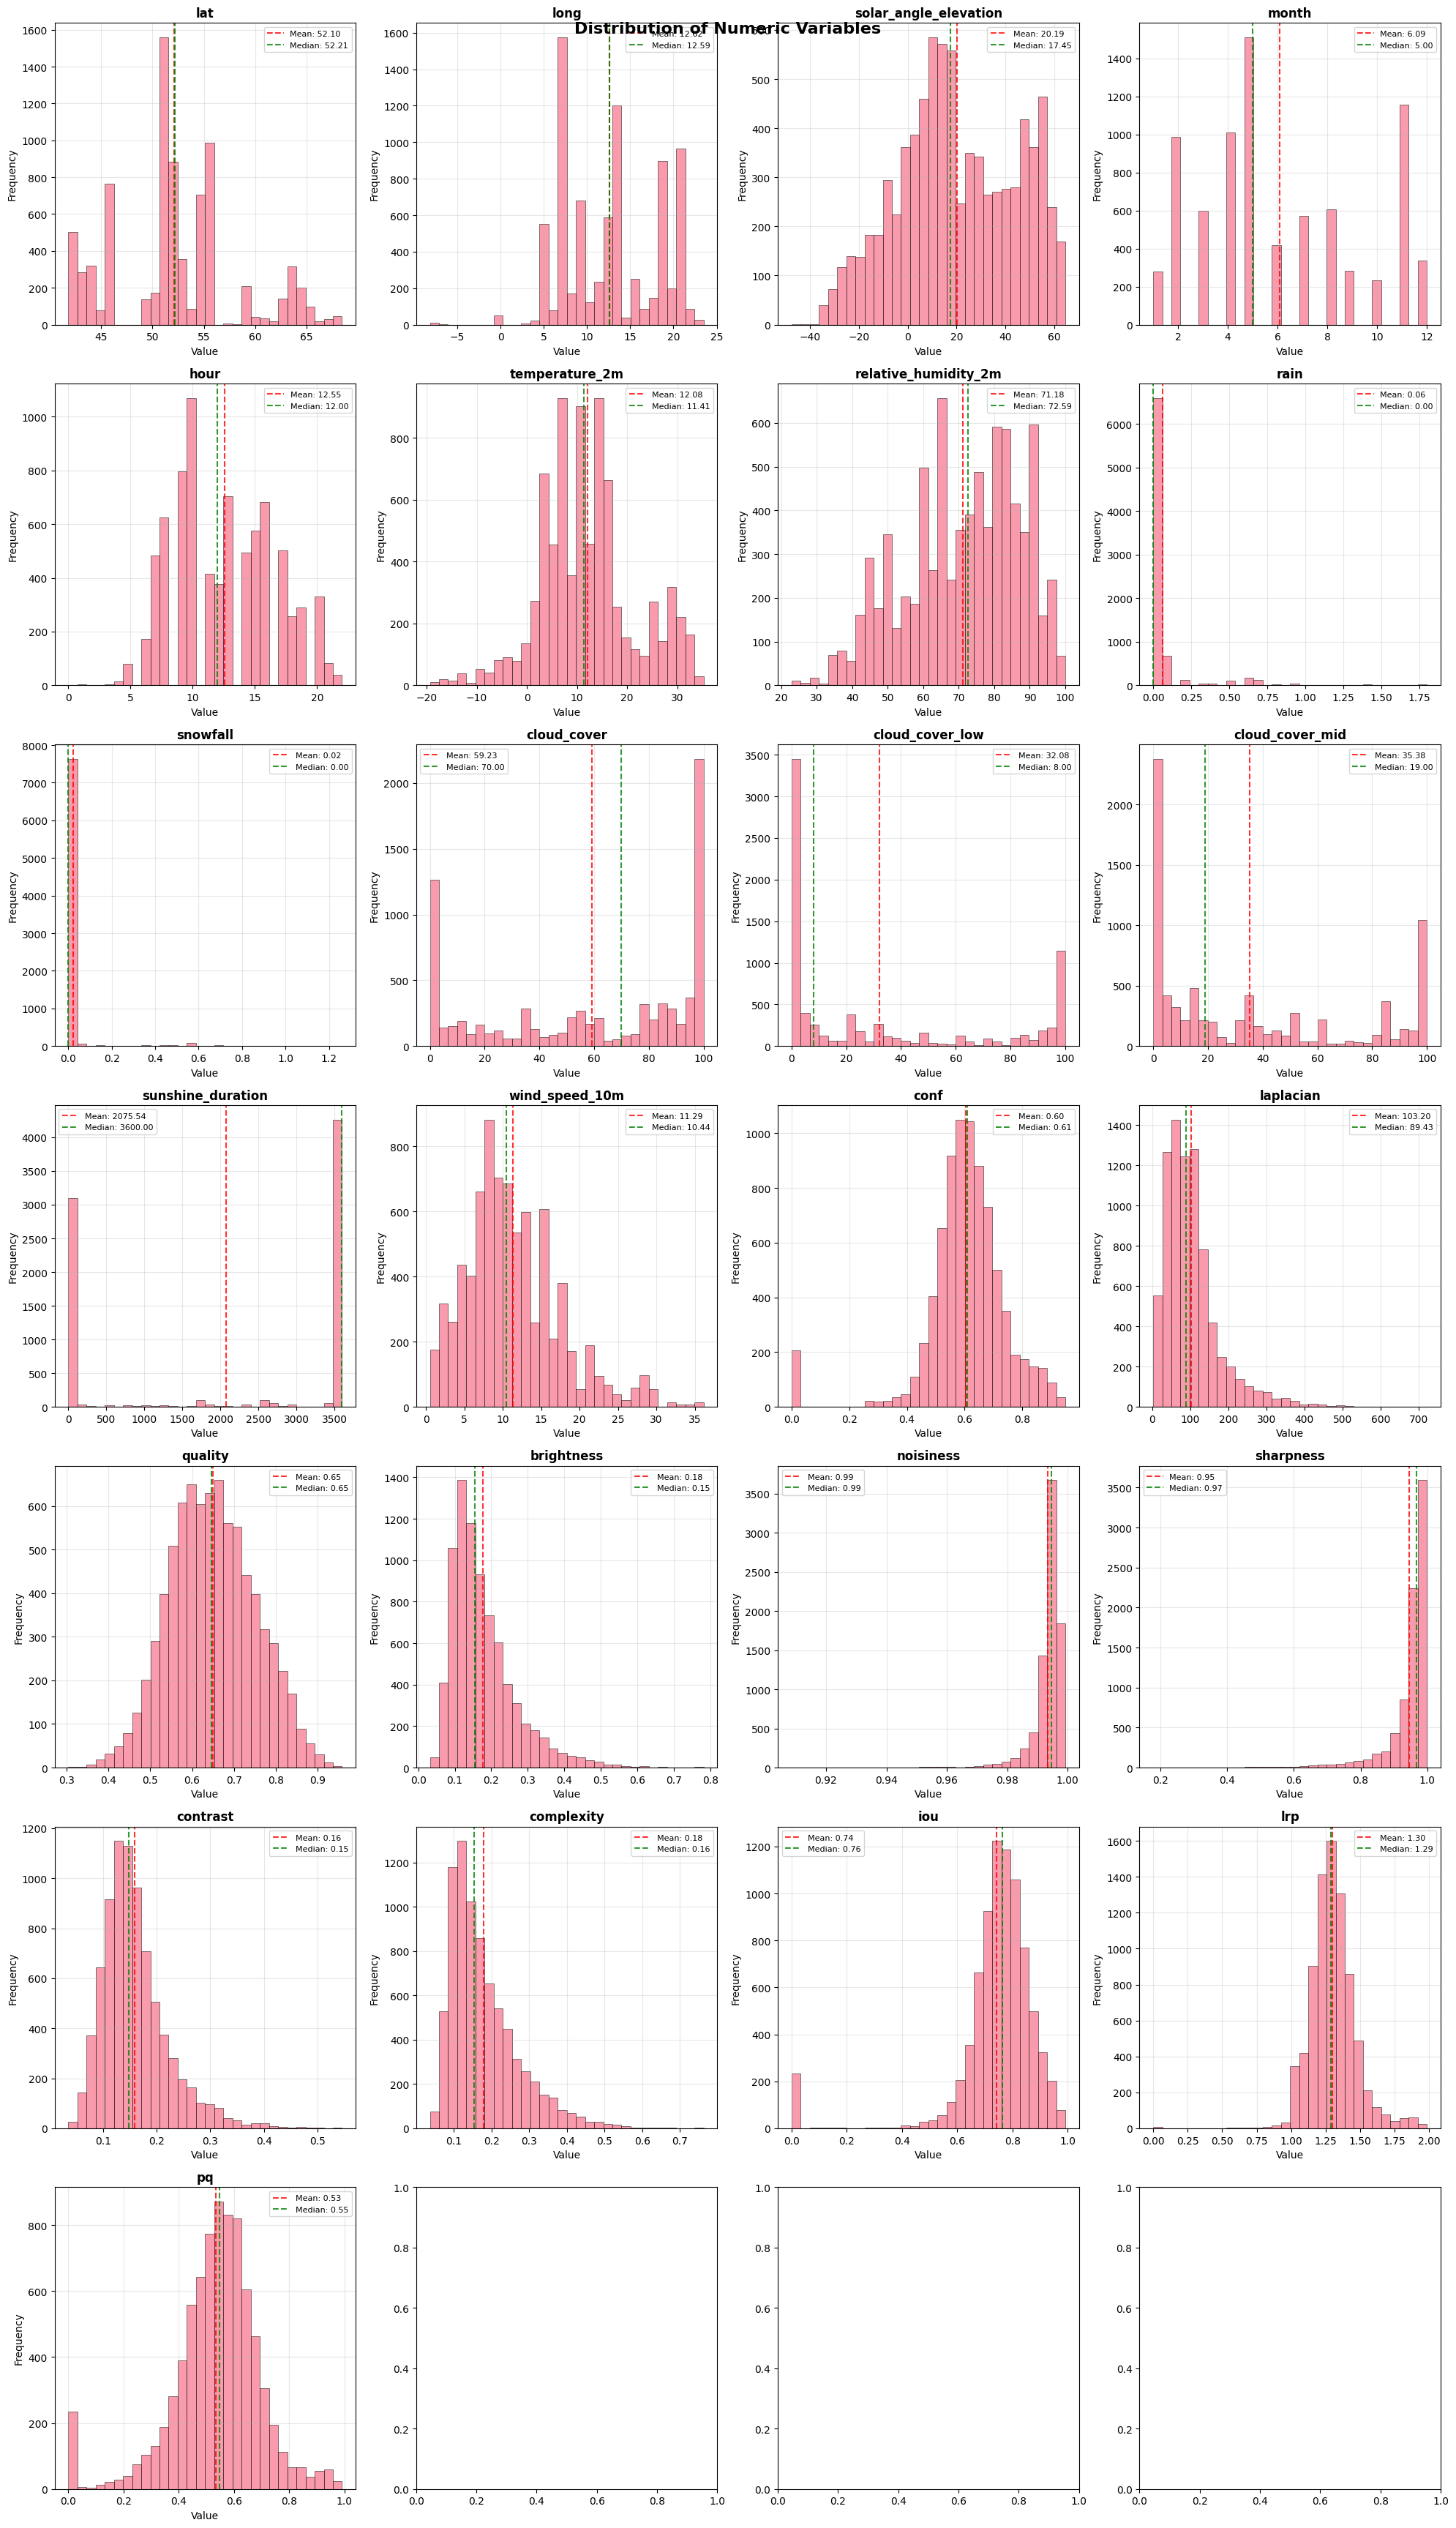

In [13]:
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Numeric Variables', fontsize=16, fontweight='bold')
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    axes[i].hist(clean_data, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

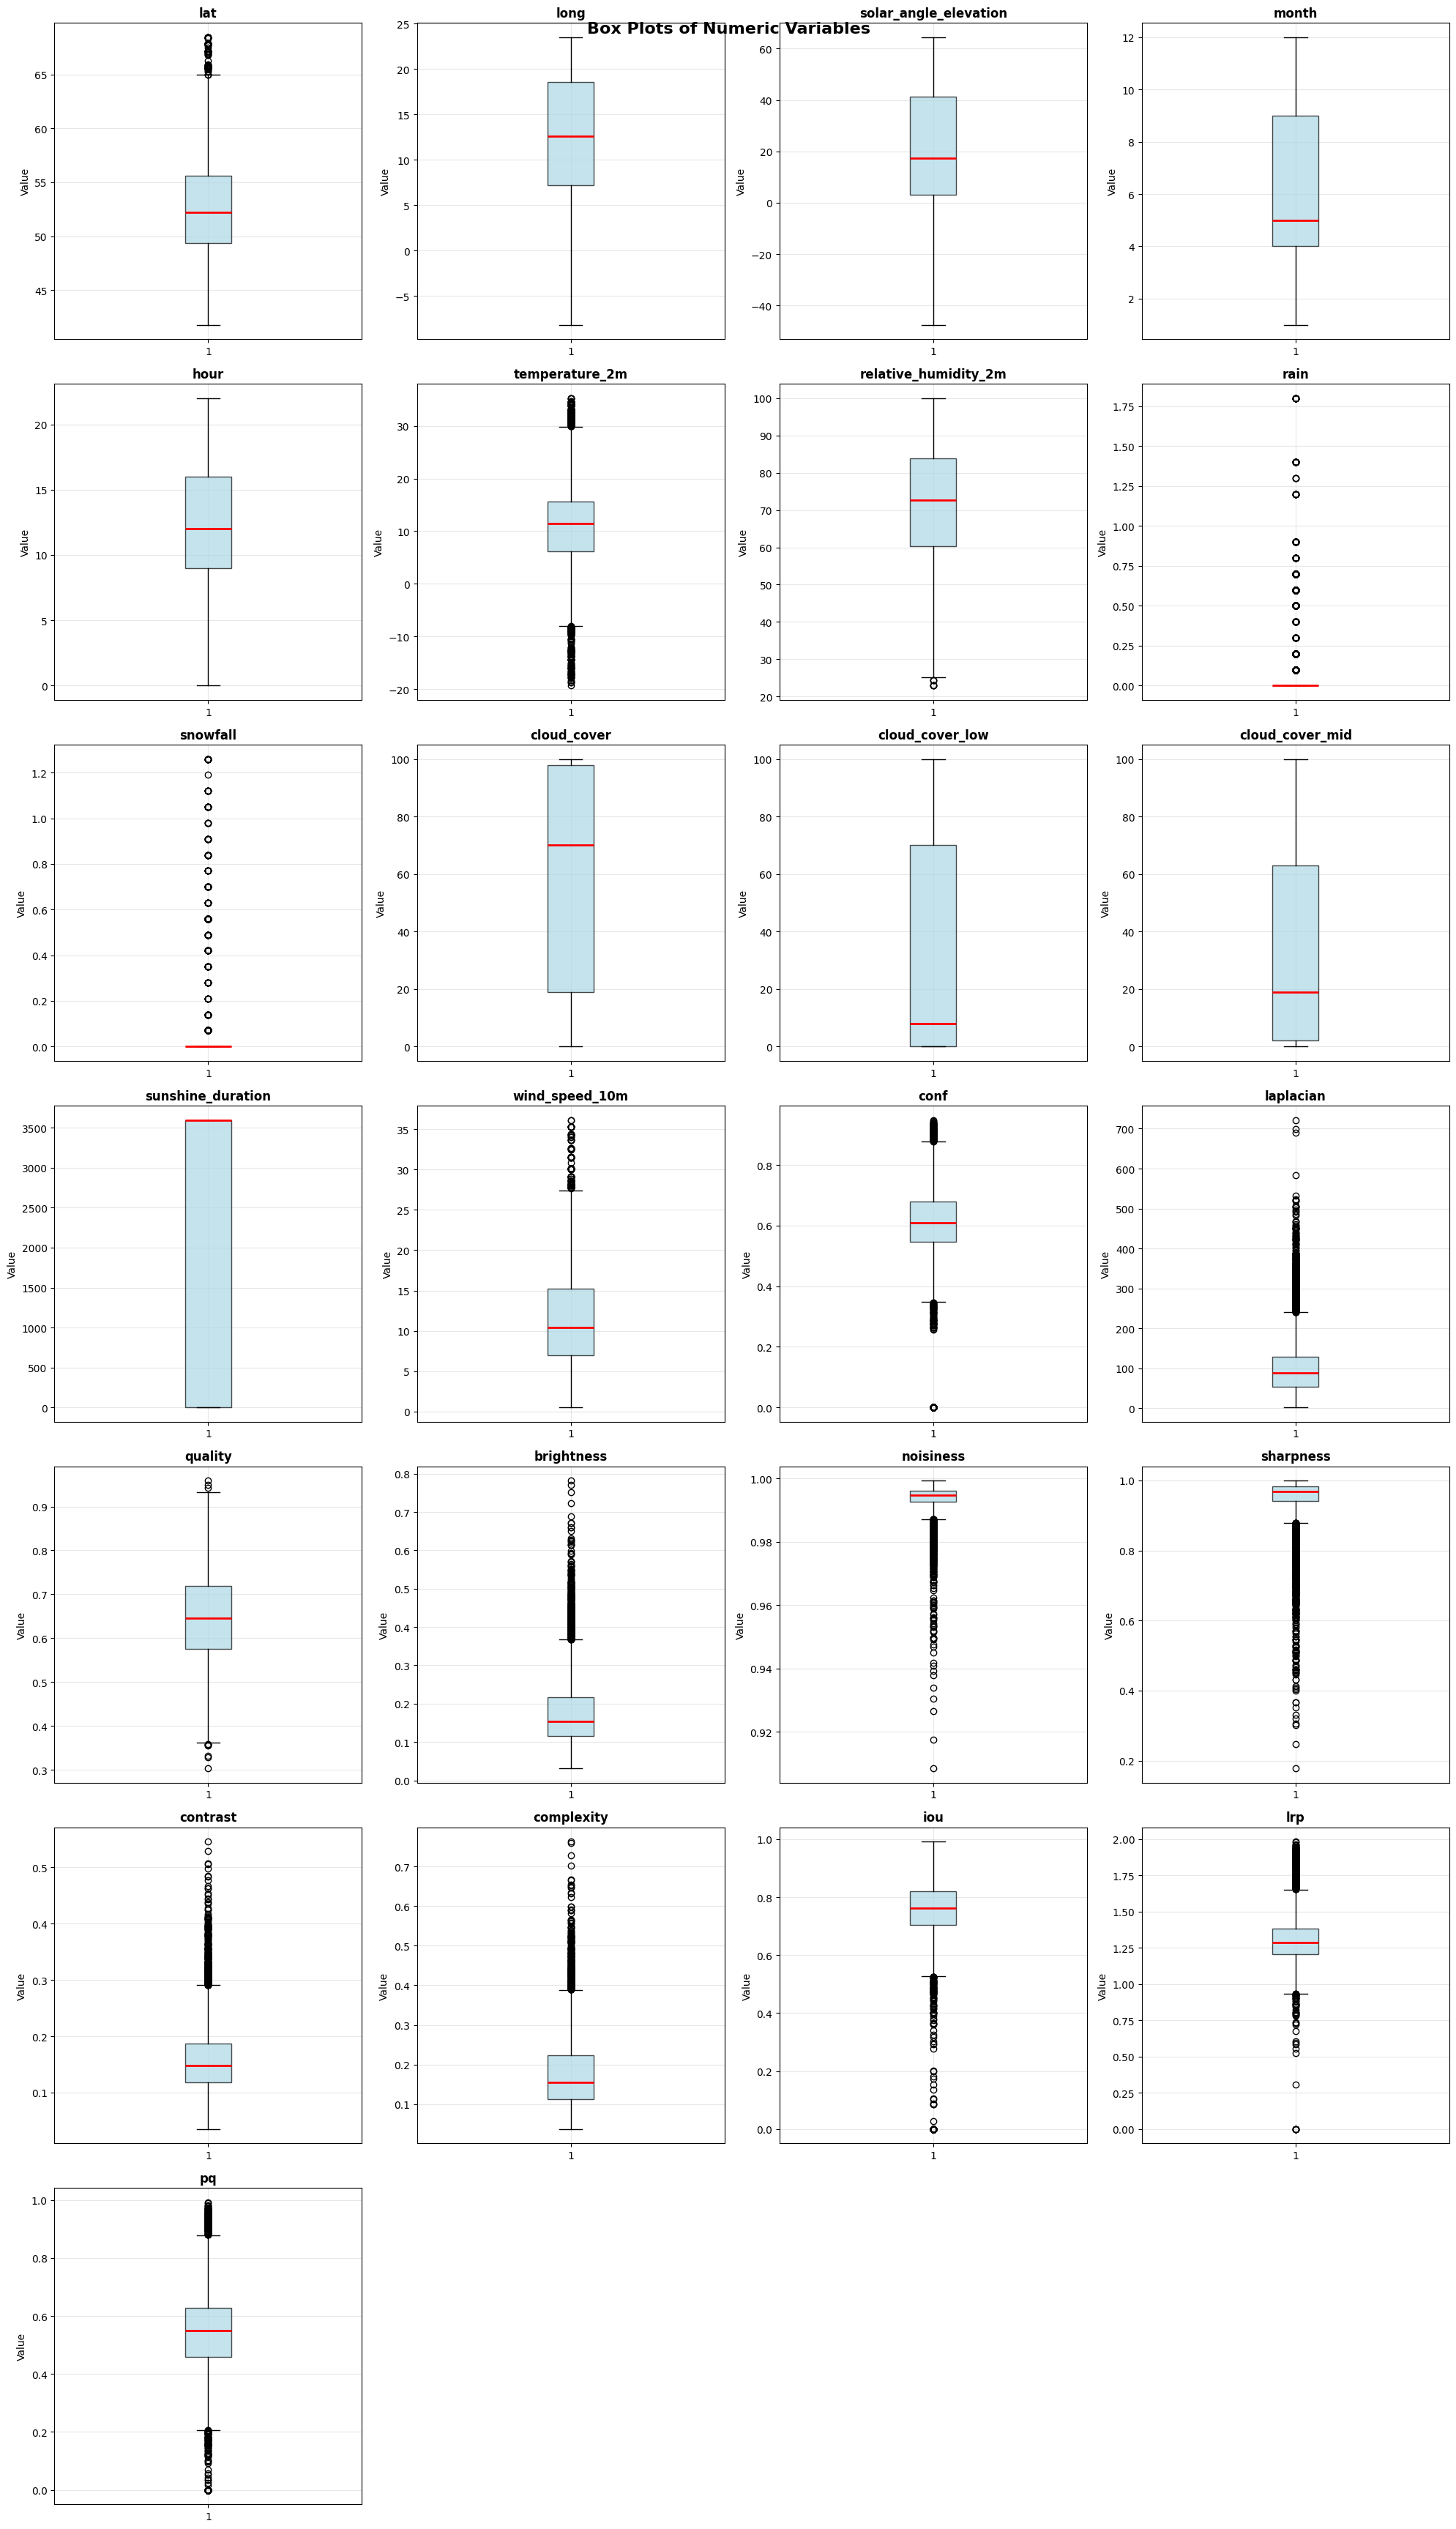

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Box Plots of Numeric Variables', fontsize=16, fontweight='bold')

# Flatten axes array for easier indexing
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    # Create box plot
    axes[i].boxplot(clean_data, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


Correlation

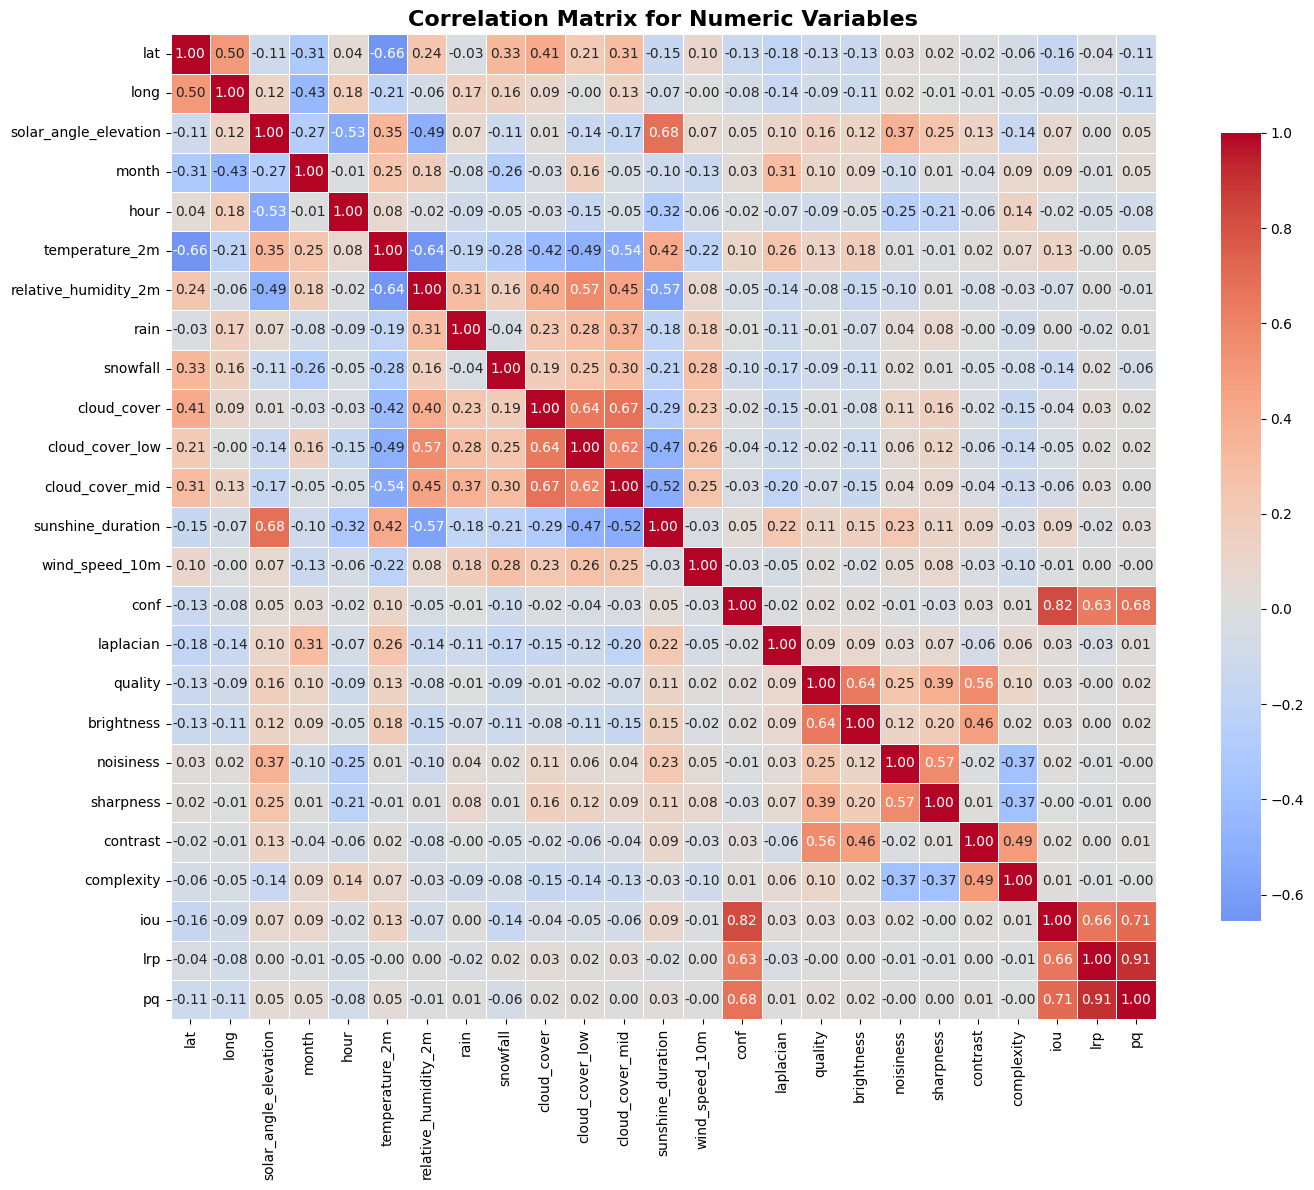

In [15]:
numeric_data = data[numeric_columns].select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr('pearson')

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix for Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Bivariate Correlation

Bivariate correlations between all these features and against the pass/fail result (success rate) for an instance

### Categorical Var

Use Etta-square for correlation between varaibles and IoU.
It measures the proportion of variance associated with each main effect and interaction effect in an ANOVA model.

In [33]:
def compute_cat_correlations(data, categorical_columns, target_column='iou'):
    categorical_correlations = []

    for col in categorical_columns:
        categories = data[col].unique()
        groups = [data[data[col] == cat][target_column].values for cat in categories]
        groups = [group for group in groups if len(group) > 0]  
        
        if len(groups) >= 2:
            overall_mean = data[target_column].mean()
            ssb = sum(len(group) * (np.mean(group) - overall_mean)**2 for group in groups)
            sst = sum((data[target_column] - overall_mean)**2)
            eta_squared = ssb / sst if sst != 0 else 0
            categorical_correlations.append({'col': col,'Eta_Squared': eta_squared,})

    categorical_corr_df = pd.DataFrame(categorical_correlations)
    categorical_corr_df = categorical_corr_df.sort_values('Eta_Squared', ascending=False)
    return categorical_corr_df

In [34]:
categorical_iou_corr_df = compute_cat_correlations(data, categorical_columns, target_column='iou')
categorical_pq_corr_df = compute_cat_correlations(data, categorical_columns, target_column='pq')
categorical_lrp_corr_df = compute_cat_correlations(data, categorical_columns, target_column='lrp')

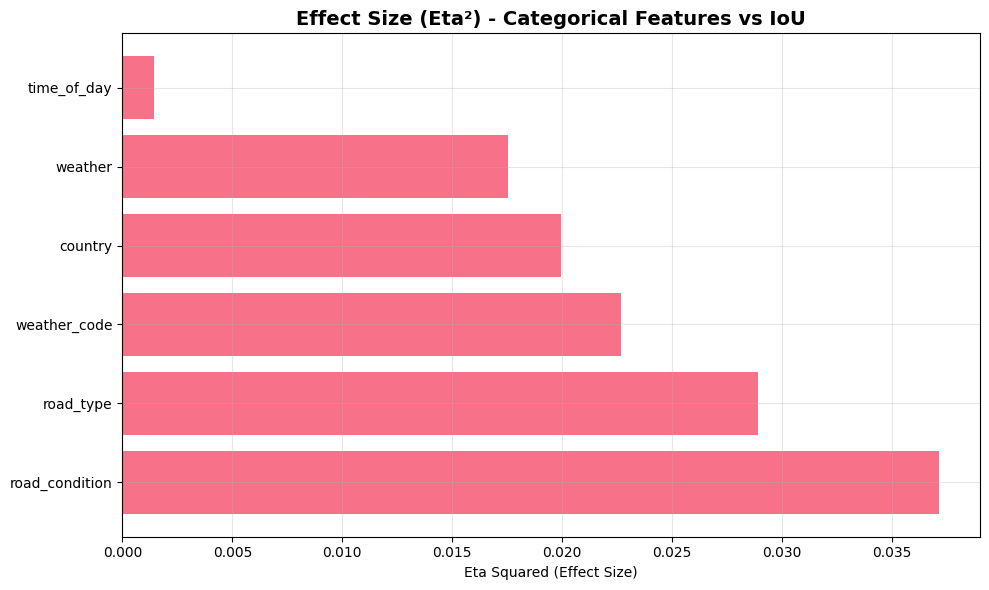

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_iou_corr_df['col'], categorical_iou_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs IoU', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

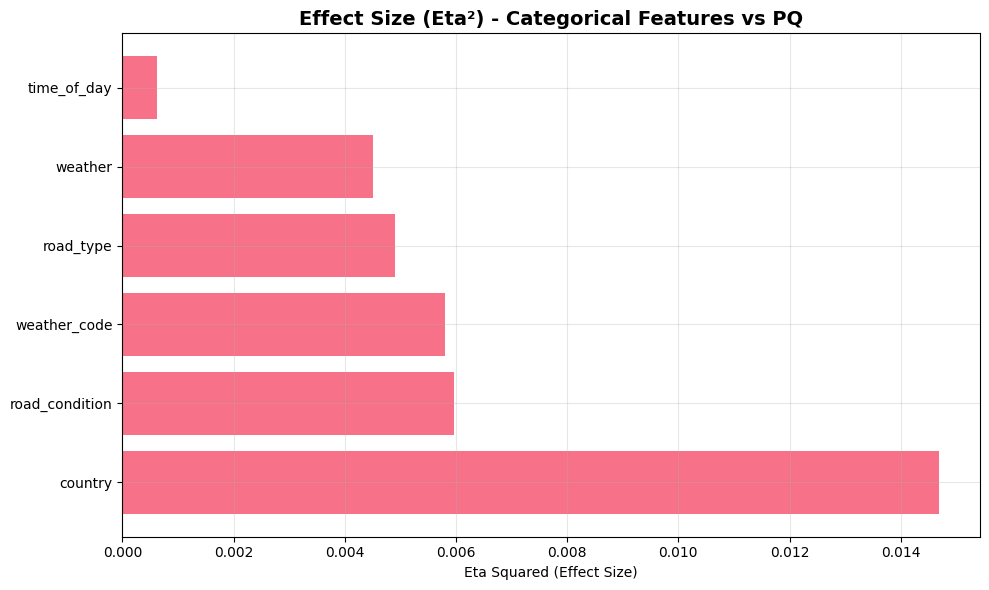

In [36]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_pq_corr_df['col'], categorical_pq_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs PQ', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

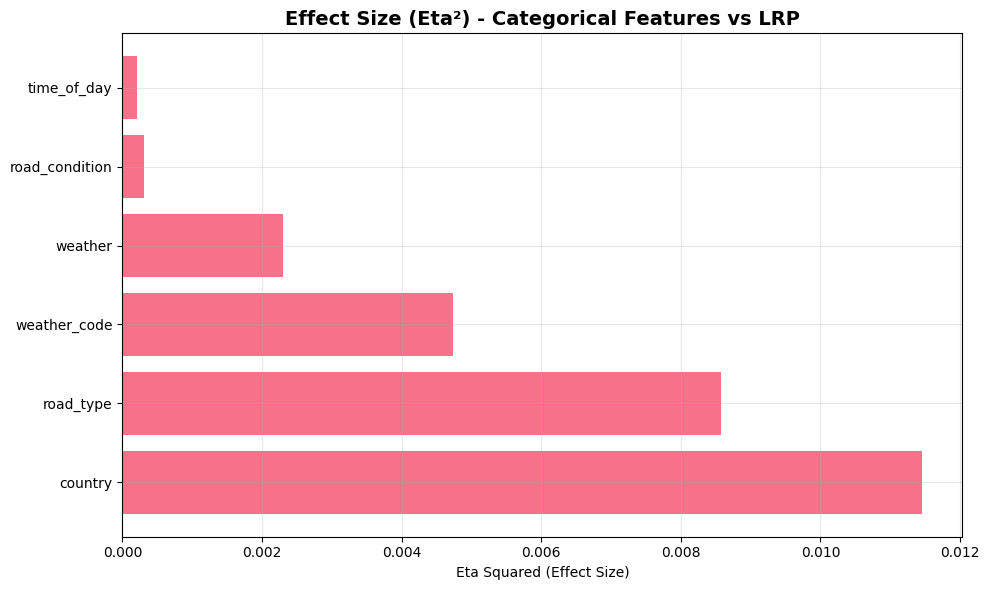

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_lrp_corr_df['col'], categorical_lrp_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs LRP', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Numerical Var

Plots relationship between variables and IoU using both Pearson and Spearman correlation. 

In [ ]:
def compute_num_correlations(data, numeric_columns, target_column='iou'):
    numeric_correlations = []

    for col in numeric_columns:
        if col == "coords":
            continue
        pearson_corr, pearson_p = pearsonr(data[col], data[target_column])
        spearman_corr, spearman_p = spearmanr(data[col], data[target_column])
        
        numeric_correlations.append({
            'col': col,
            'Pearson_Corr': pearson_corr,
            'Spearman_Corr': spearman_corr,
        })

    numeric_corr_df = pd.DataFrame(numeric_correlations)
    numeric_corr_df = numeric_corr_df.sort_values('Pearson_Corr', key=abs, ascending=False)
    return numeric_corr_df

In [39]:
numeric_corr_df_iou = compute_num_correlations(data, numeric_columns, target_column='iou')
numeric_corr_df_pq = compute_num_correlations(data, numeric_columns, target_column='pq')
numeric_corr_df_lrp = compute_num_correlations(data, numeric_columns, target_column='lrp')


<Figure size 640x480 with 0 Axes>

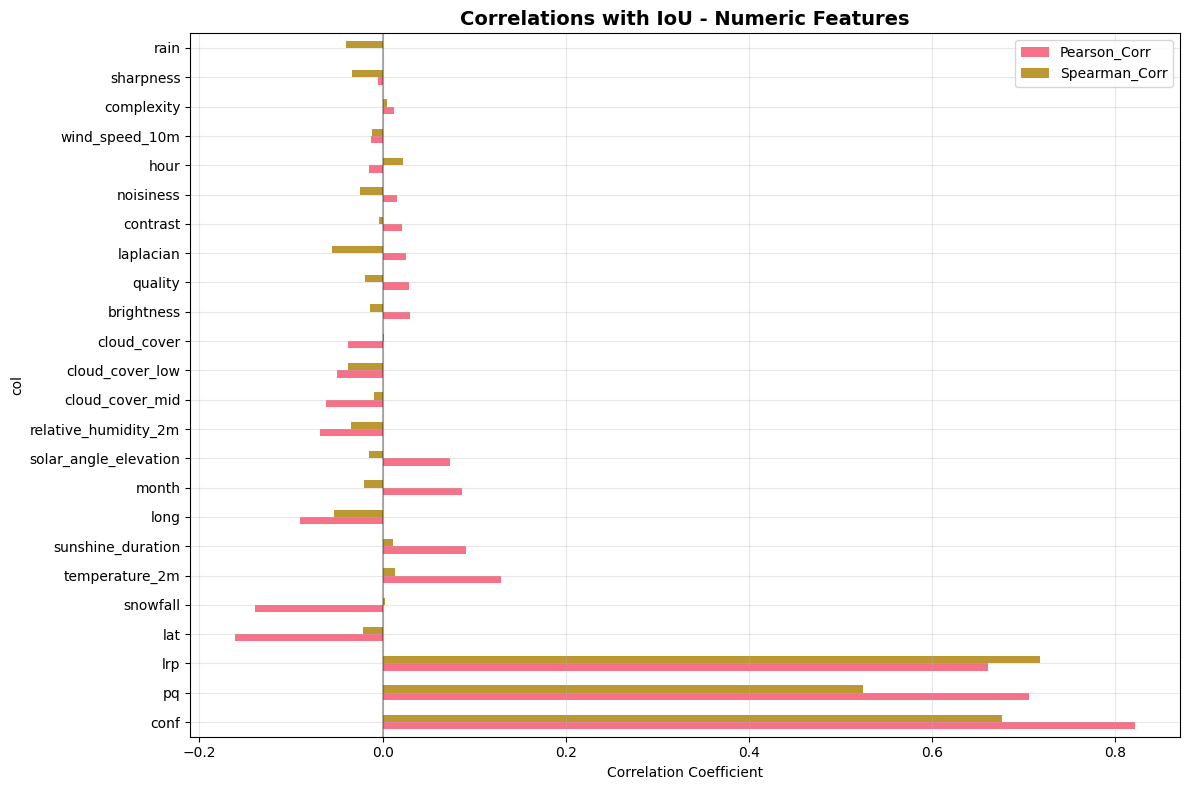

In [40]:
plt.figure()
correlations_plot = numeric_corr_df_iou.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with IoU - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

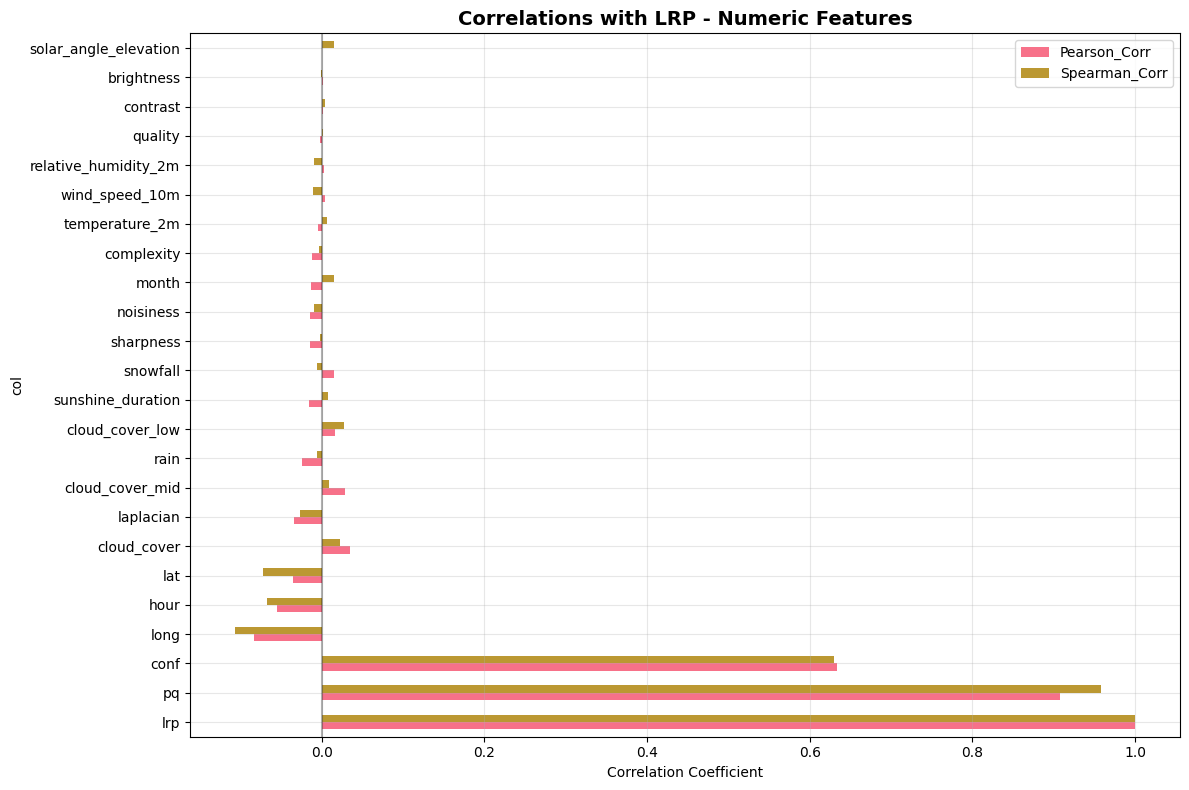

In [41]:
plt.figure()
correlations_plot = numeric_corr_df_lrp.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with LRP - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
correlations_plot = numeric_corr_df_pq.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with PQ - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Characteristic Curves

Success rate (IoU) vs Relevant or Irrelevant feature. Try this for both. Are of curve = capability. Also Black dashed line is added to show the linear regression for the black points (pass/fail). 

The conformances (Spearman correlations against monotonic sequence) are 0.80, 0.60, 1.00 and −0.50, respectively. Dont completly understand this.

## Agent Characteristic Grids

Placing each feature as a dimension and the success rate (or other performance metric) represented in colours (or shade of grey).

# Assessor Tests

### Baseline

Confidence vs IoU

In [21]:
baseline = r2_score(data["iou"], data["conf"])
print(f"R2 score of baseline {baseline}")

R2 score of baseline -0.08647424468503795


Random Prediction (Normal dist)

In [22]:
random_iou = np.random.normal(loc=0.5, scale=0.5, size=len(data))
random_iou = np.clip(random_iou, 0, 1)
random_baseline_r2 = r2_score(data["iou"], random_iou)
print(f"R2 score of random baseline: {random_baseline_r2:.4f}")

R2 score of random baseline: -7.4357


### Models

Split data into train 60% and validation 40%

In [23]:
#X_train, X_test, y_train, y_test = train_test_split(data, test_size=0.4, train_size=0.6, stratify=data["iou"])
X_train, X_test = train_test_split(data, test_size=0.4, train_size=0.6)
y_train = X_train["iou"]
del X_train["iou"]

y_test = X_test["iou"]
del X_test["iou"]

print("X:", len(X_train), len(X_test))
print("y:", len(y_train), len(y_test))
print(X_train.columns)

X: 4799 3200
y: 4799 3200
Index(['country', 'time_of_day', 'lat', 'long', 'road_type', 'road_condition',
       'weather', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'rain', 'snowfall', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'sunshine_duration',
       'wind_speed_10m', 'weather_code', 'laplacian', 'quality', 'brightness',
       'noisiness', 'sharpness', 'contrast', 'complexity', 'conf', 'lrp',
       'pq'],
      dtype='object')


In [24]:
train_numeric_columns = numeric_columns.remove("iou")
train_categorical_columns = categorical_columns

Train models with cv and then test.

#### Linear Regression

In [25]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

linear_reg = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
cv_lr = cross_validate(linear_reg, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_lr["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_lr["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_lr["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_lr["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_lr["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_lr["test_neg_mean_squared_error"])}")

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/felix/miniconda3/envs/predictable-ad/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/felix/miniconda3/envs/predictable-ad/lib/python3.12/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/felix/miniconda3/envs/predictable-ad/lib/python3.12/site-packages/sklearn/pipeline.py", line 653, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
linear_reg.fit(X_train, y_train)

y_pred = linear_reg.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.7029222599152108


#### Decision Trees

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

decision_tree = Pipeline([("preprocessor", preprocessor), ("model", DecisionTreeRegressor())])
cv_dt = cross_validate(decision_tree, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_dt["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_dt["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_dt["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_dt["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_dt["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_dt["test_neg_mean_squared_error"])}")

Mean CV train r2 score 1.0
Mean CV test r2 score 0.3215459901157173
Mean CV train MAE score 0.0
Mean CV test MAE score -0.10299420087306357
Mean CV train MSE score 0.0
Mean CV test MSE score -0.02200415557138811


In [ ]:
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.366054967638343


#### Random Forest

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

rand_forest = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor())])
cv_rf = cross_validate(rand_forest, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_rf["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_rf["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_rf["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_rf["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_rf["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_rf["test_neg_mean_squared_error"])}")

Mean CV train r2 score 0.9483597208103527
Mean CV test r2 score 0.6300941494533823
Mean CV train MAE score -0.02840706310011396
Mean CV test MAE score -0.07626452672373799
Mean CV train MSE score -0.0016924133349907136
Mean CV test MSE score -0.012040165981148532


In [ ]:
rand_forest.fit(X_train, y_train)
y_pred = rand_forest.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.6557697366025709


#### MLP

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

mlp = Pipeline([("preprocessor", preprocessor), ("model", MLPRegressor())])
cv_mlp = cross_validate(mlp, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_mlp["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_mlp["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_mlp["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_mlp["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_mlp["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_mlp["test_neg_mean_squared_error"])}")

Mean CV train r2 score 0.6974727776361284
Mean CV test r2 score 0.64284135225963
Mean CV train MAE score -0.07196505446635526
Mean CV test MAE score -0.07740483907330398
Mean CV train MSE score -0.009913164674800018
Mean CV test MSE score -0.011646171791145467


In [ ]:
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.6669200919274898
